# Turn Validation
Thin notebook that reuses `validation_plots.shared_validation` plotting functions.

In [1]:
from pathlib import Path
import os
import subprocess
import tkinter as tk
from tkinter import filedialog
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from imu_features.config import PipelineConfig
import validation_plots.shared_validation as sv


In [2]:
DATA_ROOT = Path("Data")
PATIENT_ID = "patient_111"
DATE = '2026-04-29'             # e.g. "2026-03-08" or None => latest
USE_TKINTER_CHOOSER = False      # set True to open folder chooser UI

PLOT_PARAMS = {
    "pause_min_duration_beta": 0.6,
    "turn_compare_fs_hz": 10,
    "turn_compare_min_amp": 0.20,          # fallback only for turn wavelet estimate
    "turn_compare_threshold_k": 4.0,
    "turn_compare_min_t_sec": 0.5,
    "turn_compare_step_freq_hz": (0.4, 2),
    "turn_compare_window_sec": 0.5,
    "window_gate": {
        "window_sec": 0.4,
        "turn_min_amp_threshold": 0.10,    # fallback only
        "turn_threshold_k": 5.0,
        "turn_min_duration_s": 0.8,
    },
}

COLUMN_MAPPING_OVERRIDE = {
    "timestamp": ["Timestamp", "timestamp", "time", "Time"],
    "accel_x": ["Accel_X", "accel_x", "acc_x"],
    "accel_y": ["Accel_Y", "accel_y", "acc_y"],
    "accel_z": ["Accel_Z", "accel_z", "acc_z"],
    "useracc_x": ["UserAccel_X", "useracc_x", "linacc_x", "linearacc_x"],
    "useracc_y": ["UserAccel_Y", "useracc_y", "linacc_y", "linearacc_y"],
    "useracc_z": ["UserAccel_Z", "useracc_z", "linacc_z", "linearacc_z"],
    "gyro_x": ["Gyro_X", "gyro_x", "gyr_x"],
    "gyro_y": ["Gyro_Y", "gyro_y", "gyr_y"],
    "gyro_z": ["Gyro_Z", "gyro_z", "gyr_z"],
}

PIPELINE_CONFIG = PipelineConfig()
PIPELINE_CONFIG.column_candidates = COLUMN_MAPPING_OVERRIDE
print("Turn config ready")


Turn config ready


In [3]:
CHOSEN_DIR = None

def _activate_notebook_process_for_dialog():
    if os.name != "posix":
        return
    try:
        subprocess.run(
            [
                "osascript",
                "-e",
                (
                    'tell application "System Events" '
                    f'to set frontmost of first process whose unix id is {os.getpid()} to true'
                ),
            ],
            check=False,
            capture_output=True,
            text=True,
        )
    except Exception:
        pass

def choose_directory_tkinter(initial_dir=None):
    try:
        _activate_notebook_process_for_dialog()
        root = tk.Tk()
        root.withdraw()
        root.attributes("-topmost", True)
        root.lift()
        root.focus_force()
        root.update()
        root.update_idletasks()
        try:
            root.eval('tk::PlaceWindow . center')
        except Exception:
            pass
        _activate_notebook_process_for_dialog()
        selected = filedialog.askdirectory(
            parent=root,
            initialdir=str(Path(initial_dir or DATA_ROOT).resolve()),
            title="Choose activity date folder",
            mustexist=True,
        )
        root.attributes("-topmost", False)
        root.destroy()
        return Path(selected) if selected else None
    except Exception as exc:
        print(f"tkinter chooser unavailable ({exc}); using configured path.")
        return None

CHOSEN_DIR = choose_directory_tkinter(initial_dir=DATA_ROOT) if USE_TKINTER_CHOOSER else None
print("Chosen directory:", CHOSEN_DIR)


Chosen directory: None


In [4]:
sv.configure(PIPELINE_CONFIG, PLOT_PARAMS)

resolve_date_dir = sv.resolve_date_dir
discover_activity_files = sv.discover_activity_files
load_activity_file = sv.load_activity_file
plot_walk_validation = sv.plot_walk_validation
plot_turn_validation = sv.plot_turn_validation
plot_transition_validation = sv.plot_transition_validation
plot_turn_symmetry_comparison = sv.plot_turn_symmetry_comparison
plot_turn_pair_xcorr = sv.plot_turn_pair_xcorr
plot_transition_pair_xcorr = sv.plot_transition_pair_xcorr

print("shared_validation helpers imported")


shared_validation helpers imported


## Base Directory

In [5]:
sv.configure(PIPELINE_CONFIG, PLOT_PARAMS)

if CHOSEN_DIR is not None:
    BASE_DIR = Path(CHOSEN_DIR)
else:
    BASE_DIR = resolve_date_dir(DATA_ROOT, PATIENT_ID, DATE)
    if DATE is None:
        DATE = BASE_DIR.name

print("Base directory:", BASE_DIR)


Base directory: Data/patient_111/2026-04-29


In [6]:
def plot_loaded_sensor(df_loaded, sensor_name, x_col, y_col, z_col, show_x=True, show_y=True, show_z=True, show_resultant=True, source_label=None):
    if df_loaded is None:
        print(f"[SKIP] {sensor_name}: no loaded activity dataframe")
        return
    if 'time_s' not in df_loaded.columns:
        print(f"[SKIP] {sensor_name}: loaded dataframe missing time_s")
        return
    needed = [x_col, y_col, z_col]
    missing = [c for c in needed if c not in df_loaded.columns]
    if missing:
        print(f"[SKIP] {sensor_name}: missing columns {missing}")
        return

    t_plot = pd.to_numeric(df_loaded['time_s'], errors='coerce').to_numpy(dtype=float)
    x = pd.to_numeric(df_loaded[x_col], errors='coerce').to_numpy(dtype=float)
    y = pd.to_numeric(df_loaded[y_col], errors='coerce').to_numpy(dtype=float)
    z = pd.to_numeric(df_loaded[z_col], errors='coerce').to_numpy(dtype=float)
    resultant = np.sqrt(x**2 + y**2 + z**2)

    plt.figure(figsize=(10, 4))
    if show_x:
        plt.plot(t_plot, x, label='x', linewidth=1.0)
    if show_y:
        plt.plot(t_plot, y, label='y', linewidth=1.0)
    if show_z:
        plt.plot(t_plot, z, label='z', linewidth=1.0)
    if show_resultant:
        plt.plot(t_plot, resultant, label='resultant', linewidth=1.8, color='black')
    title_suffix = f" ({source_label})" if source_label else ''
    plt.title(f"{sensor_name}{title_suffix}")
    plt.xlabel('Time (s)')
    plt.ylabel('Value')
    plt.grid(alpha=0.3)
    plt.legend(loc='upper right', fontsize=7, framealpha=0.80, borderpad=0.25, labelspacing=0.25, handlelength=1.6)
    plt.show()


## Load Left Turn File

In [7]:
sv.configure(PIPELINE_CONFIG, PLOT_PARAMS)
activity_files = discover_activity_files(BASE_DIR, ["left_turn", "right_turn"])
print("Discovered activity files:")
for k, v in activity_files.items():
    print(f"  {k}: {v}")
LEFT_TURN_PATH = activity_files.get("left_turn")
LEFT_TURN_DF = None
LEFT_TURN_META = None
LEFT_TURN_SUMMARY = None
LEFT_TURN_CACHE = None
if LEFT_TURN_PATH is not None:
    print(f"\n[PROCESS] left_turn: {LEFT_TURN_PATH}")
    LEFT_TURN_DF, LEFT_TURN_META = load_activity_file(LEFT_TURN_PATH)
    print("Loaded plot file:", LEFT_TURN_PATH)
else:
    print("[SKIP] left_turn: not available")


Discovered activity files:
  left_turn: Data/patient_111/2026-04-29/left_turn.csv
  right_turn: Data/patient_111/2026-04-29/right_turn.csv

[PROCESS] left_turn: Data/patient_111/2026-04-29/left_turn.csv
Loaded plot file: Data/patient_111/2026-04-29/left_turn.csv


## Left Turn Accelerometer

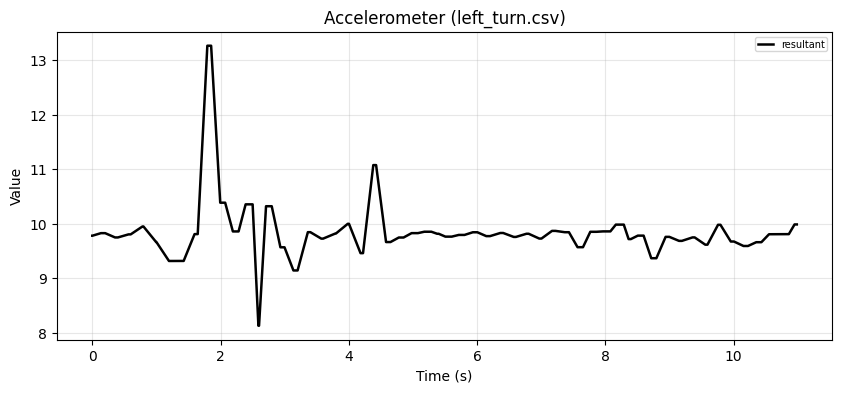

In [8]:
SHOW_ACCEL_X = False
SHOW_ACCEL_Y = False
SHOW_ACCEL_Z = False
SHOW_ACCEL_RESULTANT = True
plot_loaded_sensor(LEFT_TURN_DF, "Accelerometer", "accel_x", "accel_y", "accel_z", SHOW_ACCEL_X, SHOW_ACCEL_Y, SHOW_ACCEL_Z, SHOW_ACCEL_RESULTANT, source_label=LEFT_TURN_PATH.name if LEFT_TURN_PATH else None)


## Left Turn Gyroscope

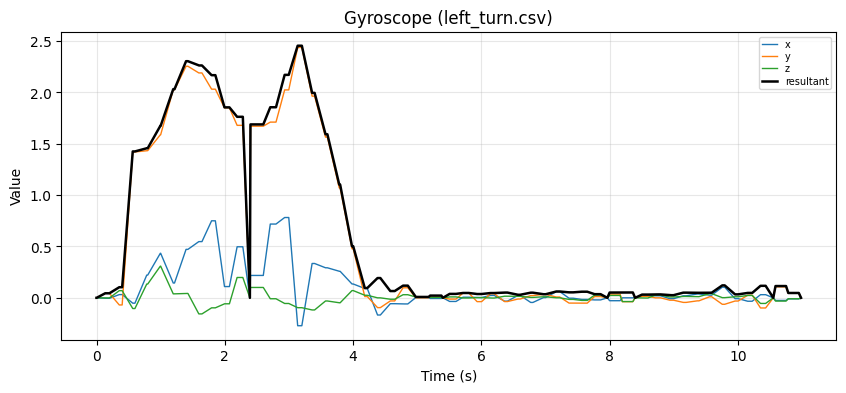

In [9]:
SHOW_GYRO_X = True
SHOW_GYRO_Y = True
SHOW_GYRO_Z = True
SHOW_GYRO_RESULTANT = True
plot_loaded_sensor(LEFT_TURN_DF, "Gyroscope", "gyro_x", "gyro_y", "gyro_z", SHOW_GYRO_X, SHOW_GYRO_Y, SHOW_GYRO_Z, SHOW_GYRO_RESULTANT, source_label=LEFT_TURN_PATH.name if LEFT_TURN_PATH else None)


## Left Turn User Accelerometer

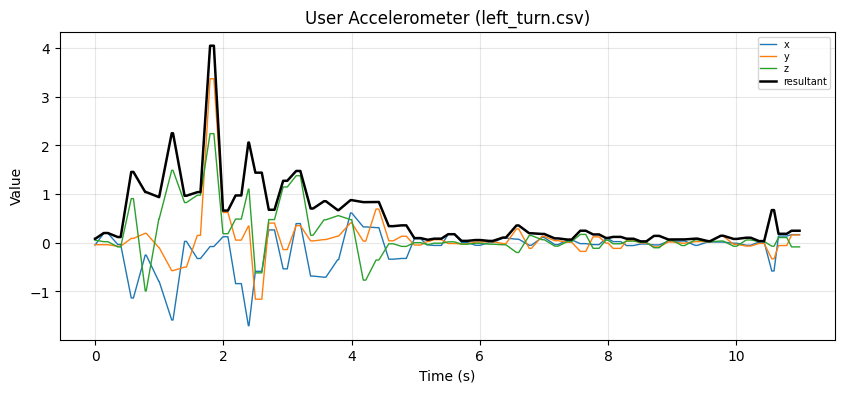

In [10]:
SHOW_USERACC_X = True
SHOW_USERACC_Y = True
SHOW_USERACC_Z = True
SHOW_USERACC_RESULTANT = True
plot_loaded_sensor(LEFT_TURN_DF, "User Accelerometer", "useracc_x", "useracc_y", "useracc_z", SHOW_USERACC_X, SHOW_USERACC_Y, SHOW_USERACC_Z, SHOW_USERACC_RESULTANT, source_label=LEFT_TURN_PATH.name if LEFT_TURN_PATH else None)


## Left Turn Feature Plots

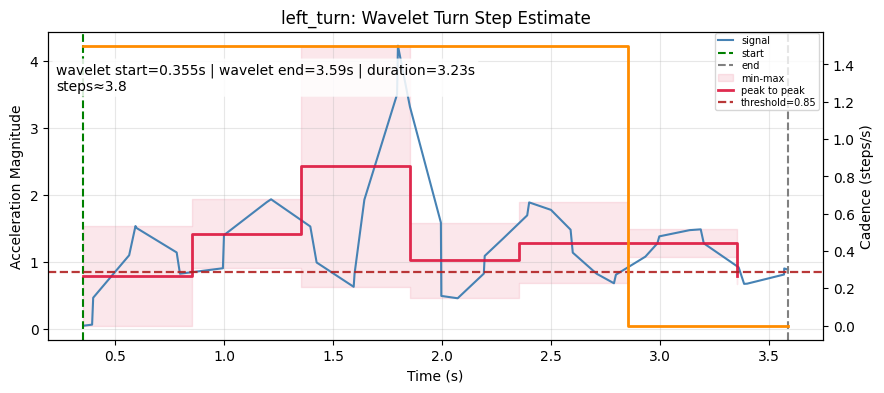

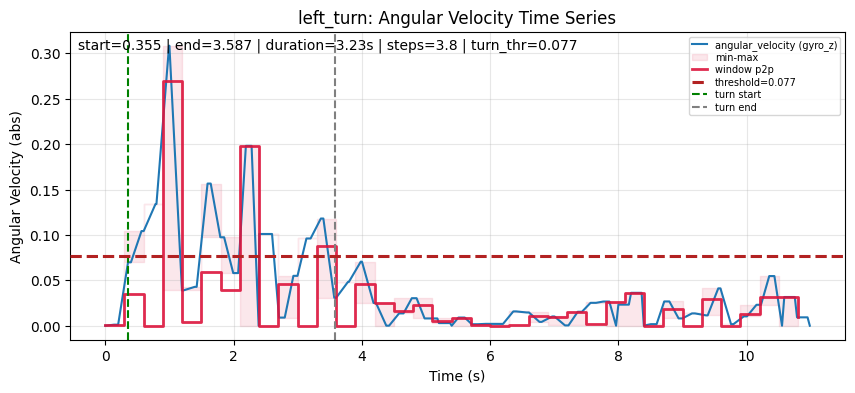

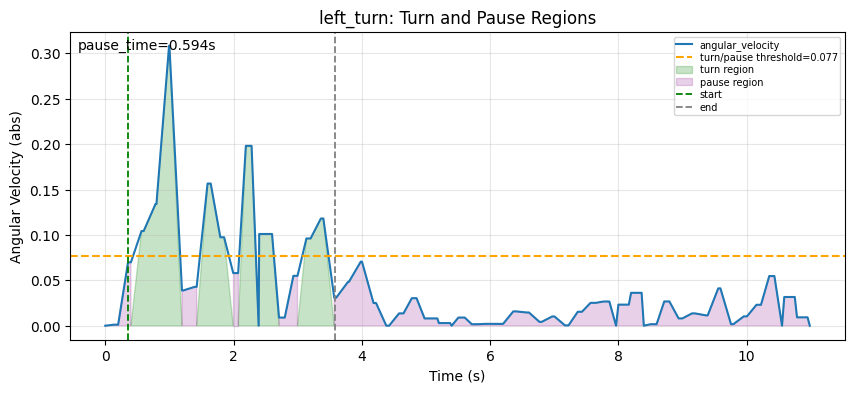

{'activity': 'left_turn', 'start_time_s': 0.35500001907348633, 'end_time_s': 3.5870001316070557, 'duration_s': 3.2320001125335693, 'step_count': 3.750000000000002, 'pause_duration': 0.5940001010894775}


,activity,start_time_s,end_time_s,duration_s,step_count,pause_duration
0,left_turn,0.355,3.587,3.232,3.75,0.594


In [11]:
if LEFT_TURN_DF is not None and LEFT_TURN_META is not None:
    LEFT_TURN_SUMMARY, LEFT_TURN_CACHE = plot_turn_validation("left_turn", LEFT_TURN_DF, LEFT_TURN_META)
    print(LEFT_TURN_SUMMARY)
    display(pd.DataFrame([LEFT_TURN_SUMMARY]))
else:
    print("[SKIP] left_turn feature plots: left turn file not loaded")


## Load Right Turn File

In [12]:
RIGHT_TURN_PATH = activity_files.get("right_turn")
RIGHT_TURN_DF = None
RIGHT_TURN_META = None
RIGHT_TURN_SUMMARY = None
RIGHT_TURN_CACHE = None
if RIGHT_TURN_PATH is not None:
    print(f"\n[PROCESS] right_turn: {RIGHT_TURN_PATH}")
    RIGHT_TURN_DF, RIGHT_TURN_META = load_activity_file(RIGHT_TURN_PATH)
    print("Loaded plot file:", RIGHT_TURN_PATH)
else:
    print("[SKIP] right_turn: not available")



[PROCESS] right_turn: Data/patient_111/2026-04-29/right_turn.csv
Loaded plot file: Data/patient_111/2026-04-29/right_turn.csv


## Right Turn Accelerometer

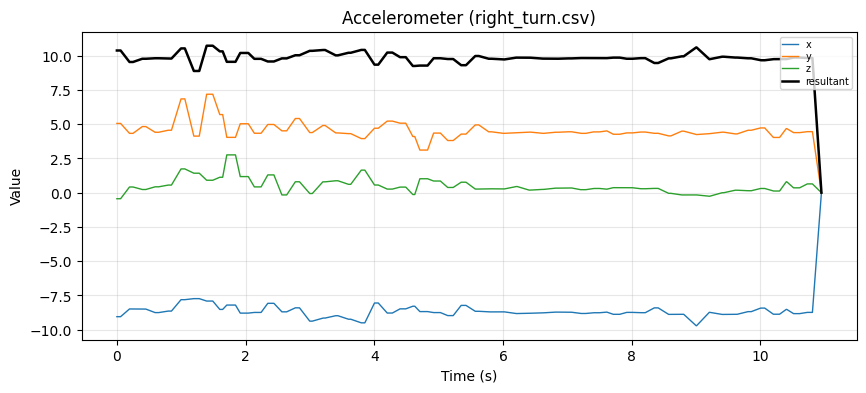

In [13]:
SHOW_ACCEL_X = True
SHOW_ACCEL_Y = True
SHOW_ACCEL_Z = True
SHOW_ACCEL_RESULTANT = True
plot_loaded_sensor(RIGHT_TURN_DF, "Accelerometer", "accel_x", "accel_y", "accel_z", SHOW_ACCEL_X, SHOW_ACCEL_Y, SHOW_ACCEL_Z, SHOW_ACCEL_RESULTANT, source_label=RIGHT_TURN_PATH.name if RIGHT_TURN_PATH else None)


## Right Turn Gyroscope

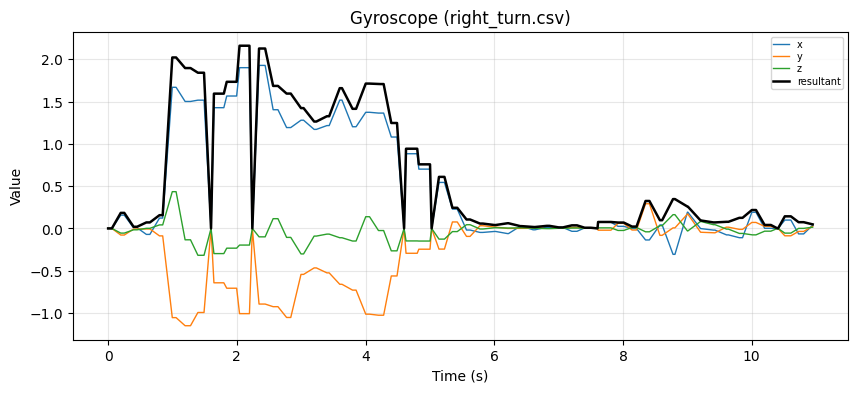

In [14]:
SHOW_GYRO_X = True
SHOW_GYRO_Y = True
SHOW_GYRO_Z = True
SHOW_GYRO_RESULTANT = True
plot_loaded_sensor(RIGHT_TURN_DF, "Gyroscope", "gyro_x", "gyro_y", "gyro_z", SHOW_GYRO_X, SHOW_GYRO_Y, SHOW_GYRO_Z, SHOW_GYRO_RESULTANT, source_label=RIGHT_TURN_PATH.name if RIGHT_TURN_PATH else None)


## Right Turn User Accelerometer

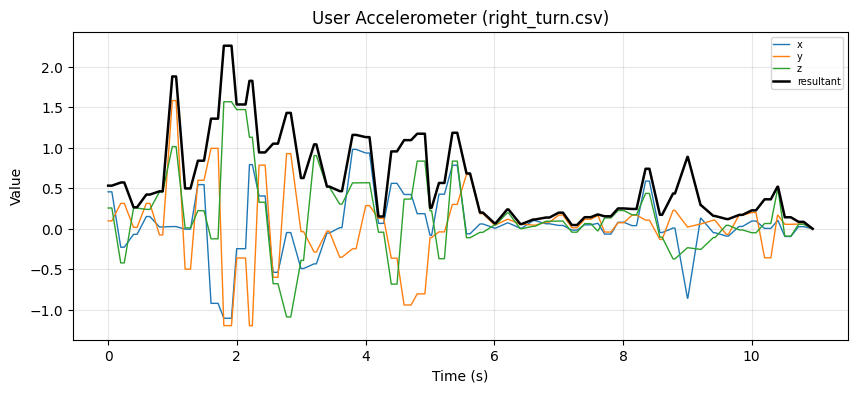

In [15]:
SHOW_USERACC_X = True
SHOW_USERACC_Y = True
SHOW_USERACC_Z = True
SHOW_USERACC_RESULTANT = True
plot_loaded_sensor(RIGHT_TURN_DF, "User Accelerometer", "useracc_x", "useracc_y", "useracc_z", SHOW_USERACC_X, SHOW_USERACC_Y, SHOW_USERACC_Z, SHOW_USERACC_RESULTANT, source_label=RIGHT_TURN_PATH.name if RIGHT_TURN_PATH else None)


## Right Turn Feature Plots

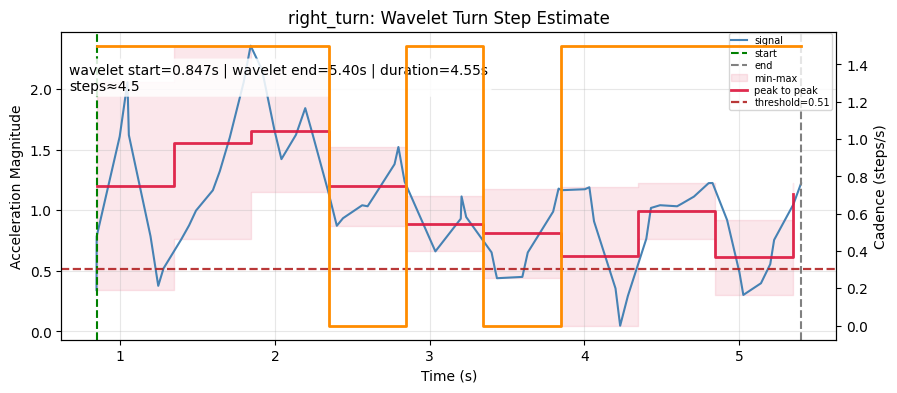

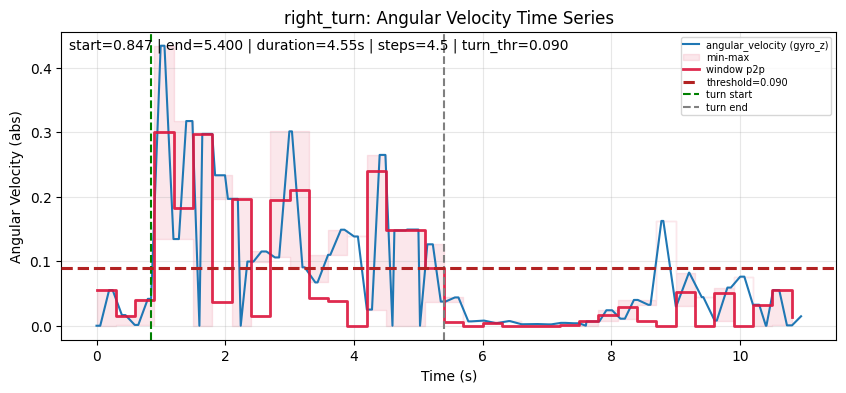

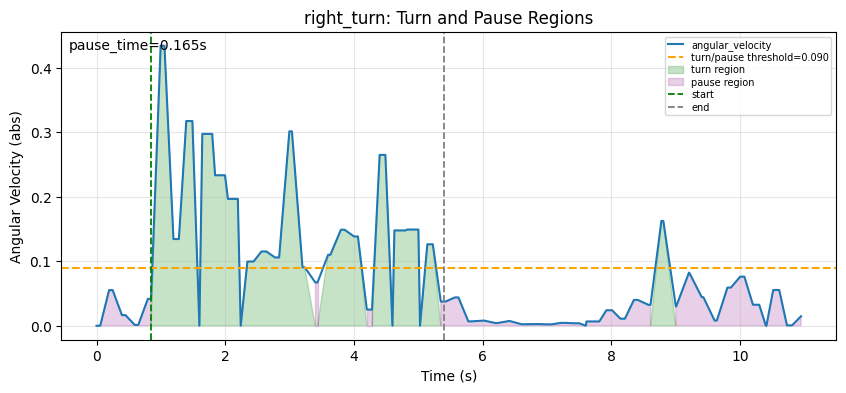

{'activity': 'right_turn', 'start_time_s': 0.8470001220703125, 'end_time_s': 5.400000095367432, 'duration_s': 4.552999973297119, 'step_count': 4.500000000000003, 'pause_duration': 0.16500020027160645}


,activity,start_time_s,end_time_s,duration_s,step_count,pause_duration
0,right_turn,0.847,5.4,4.553,4.5,0.165


In [16]:
if RIGHT_TURN_DF is not None and RIGHT_TURN_META is not None:
    RIGHT_TURN_SUMMARY, RIGHT_TURN_CACHE = plot_turn_validation("right_turn", RIGHT_TURN_DF, RIGHT_TURN_META)
    print(RIGHT_TURN_SUMMARY)
    display(pd.DataFrame([RIGHT_TURN_SUMMARY]))
else:
    print("[SKIP] right_turn feature plots: right turn file not loaded")


## Turn Comparisons

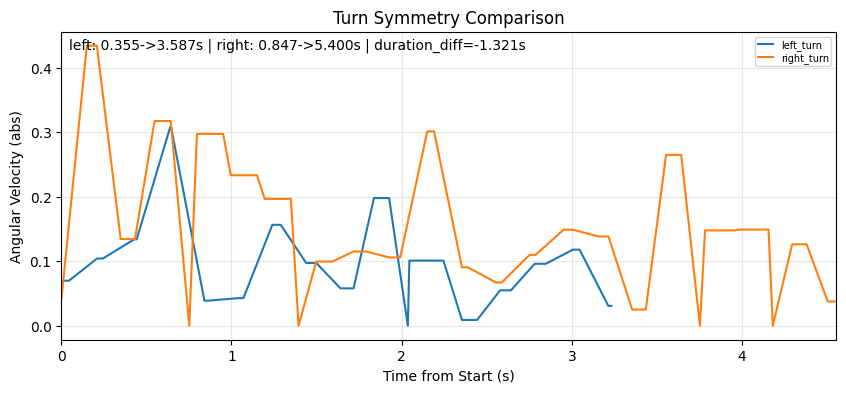

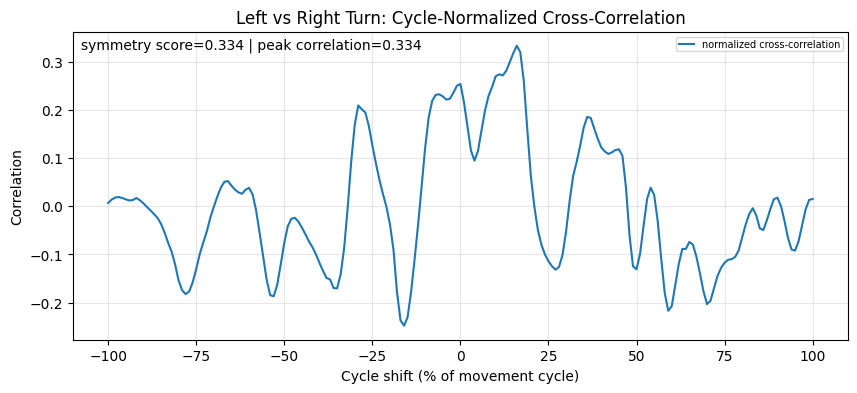

{'activity': 'turn_left_right_xcorr', 'xcorr_symmetry_score': 0.33350692827848505, 'xcorr_peak_correlation': 0.33350692827848505}

=== Validation Summary ===


,activity,start_time_s,end_time_s,duration_s,step_count,pause_duration,xcorr_symmetry_score,xcorr_peak_correlation
0,left_turn,0.355,3.587,3.232,3.75,0.594,NaN,NaN
1,right_turn,0.847,5.400,4.553,4.50,0.165,NaN,NaN
2,turn_left_right_xcorr,NaN,NaN,NaN,NaN,NaN,0.333507,0.333507


In [17]:
turn_comparisons = []
if LEFT_TURN_CACHE is not None and RIGHT_TURN_CACHE is not None:
    plot_turn_symmetry_comparison(LEFT_TURN_CACHE, RIGHT_TURN_CACHE)
    turn_corr = plot_turn_pair_xcorr(LEFT_TURN_CACHE, RIGHT_TURN_CACHE)
    turn_comparisons.append(turn_corr)
    print(turn_corr)
else:
    print("[SKIP] turn comparisons: need both left_turn and right_turn")
print("\n=== Validation Summary ===")
display(pd.DataFrame(([s for s in [LEFT_TURN_SUMMARY, RIGHT_TURN_SUMMARY] if s is not None] + turn_comparisons)))


In [ ]:
# Calculated linear and nonlinear turn features from the loaded synchronized turn files
from imu_features.turn_features import extract_turn_features


sv.configure(PIPELINE_CONFIG, PLOT_PARAMS)
sv._apply_notebook_window_gate_settings()

turn_feature_specs = [
    ("duration", "Linear"),
    ("mean_angular_velocity", "Linear"),
    ("peak_angular_velocity", "Linear"),
    ("ang_vel_std", "Linear"),
    ("pause_count", "Linear"),
    ("pause_time", "Linear"),
    ("jerk_std", "Linear"),
    ("entropy", "Nonlinear"),
]

turn_rows = []
left_turn_features = None
right_turn_features = None

if LEFT_TURN_DF is not None and LEFT_TURN_META is not None:
    left_turn_features = extract_turn_features(LEFT_TURN_DF, LEFT_TURN_META, PIPELINE_CONFIG, prefix="left_turn")
    for suffix, feature_type in turn_feature_specs:
        feature = f"left_turn_{suffix}"
        turn_rows.append({
            "Activity": "left_turn",
            "Feature": feature,
            "Type": feature_type,
            "Value": left_turn_features.get(feature, np.nan),
        })
else:
    print("[SKIP] left turn values: left turn file not loaded")

if RIGHT_TURN_DF is not None and RIGHT_TURN_META is not None:
    right_turn_features = extract_turn_features(RIGHT_TURN_DF, RIGHT_TURN_META, PIPELINE_CONFIG, prefix="right_turn")
    for suffix, feature_type in turn_feature_specs:
        feature = f"right_turn_{suffix}"
        turn_rows.append({
            "Activity": "right_turn",
            "Feature": feature,
            "Type": feature_type,
            "Value": right_turn_features.get(feature, np.nan),
        })
else:
    print("[SKIP] right turn values: right turn file not loaded")

if left_turn_features is not None and right_turn_features is not None:
    asymmetry_values = {
        "turn_duration_difference": left_turn_features.get("left_turn_duration", np.nan) - right_turn_features.get("right_turn_duration", np.nan),
        "turn_velocity_difference": left_turn_features.get("left_turn_mean_angular_velocity", np.nan) - right_turn_features.get("right_turn_mean_angular_velocity", np.nan),
        "turn_pause_difference": left_turn_features.get("left_turn_pause_time", np.nan) - right_turn_features.get("right_turn_pause_time", np.nan),
    }
    asymmetry_values.update({f"abs_{key}": abs(value) for key, value in asymmetry_values.items()})
    for feature, value in asymmetry_values.items():
        turn_rows.append({
            "Activity": "left_vs_right_turn",
            "Feature": feature,
            "Type": "Linear",
            "Value": value,
        })


if LEFT_TURN_CACHE is not None and RIGHT_TURN_CACHE is not None:
    _, _, xcorr_peak, xcorr_symmetry_score, _ = sv._best_xcorr_summary(LEFT_TURN_CACHE, RIGHT_TURN_CACHE, n_points=101)
    for feature, value in {
        "turn_left_right_xcorr_symmetry_score": xcorr_symmetry_score,
        "turn_left_right_xcorr_peak_correlation": xcorr_peak,
    }.items():
        turn_rows.append({
            "Activity": "left_vs_right_turn",
            "Feature": feature,
            "Type": "Nonlinear",
            "Value": value,
        })

if turn_rows:
    turn_feature_table = pd.DataFrame(turn_rows)
    display(turn_feature_table)
else:
    print("[SKIP] turn feature table: no turn files loaded")


,Activity,Feature,Type,Value,Function used
0,left_turn,left_turn_duration,Linear,3.900000,extract_turn_features
1,left_turn,left_turn_mean_angular_velocity,Linear,1.563073,extract_turn_features
2,left_turn,left_turn_peak_angular_velocity,Linear,2.446220,extract_turn_features
3,left_turn,left_turn_ang_vel_std,Linear,0.617371,extract_turn_features
4,left_turn,left_turn_pause_count,Linear,1.000000,extract_turn_features
5,left_turn,left_turn_pause_time,Linear,0.040000,extract_turn_features
6,left_turn,left_turn_jerk_std,Linear,30.448505,extract_turn_features
7,left_turn,left_turn_entropy,Nonlinear,0.571956,extract_turn_features
8,right_turn,right_turn_duration,Linear,4.500000,extract_turn_features
9,right_turn,right_turn_mean_angular_velocity,Linear,1.180537,extract_turn_features
